# 01 — Exploratory Data Analysis

This notebook performs a concise EDA of the UCI Cleveland heart disease dataset.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import load_heart_disease, CONTINUOUS_FEATURES, make_preprocessor
from src import plotting

DATA_PATH = PROJECT_ROOT / 'data' / 'heart_disease.csv'
X, y = load_heart_disease(DATA_PATH)
print(X.shape, y.shape)
X.head()

(242, 13) (242,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0


## Dataset overview

Check dimensions, data types, duplicate rows, missingness, and class balance.

In [2]:
display(X.describe(include='all').T)
print('Duplicate rows:', X.duplicated().sum())
print('Missing values:')
display(X.isna().sum().to_frame('n_missing'))
print('Class counts:')
display(y.value_counts().sort_index().to_frame('count'))

,count,mean,std,min,25%,50%,75%,max
age,242.0,54.549587,8.996981,29.0,48.00,56.0,61.00,77.0
sex,242.0,0.681818,0.466736,0.0,0.00,1.0,1.00,1.0
cp,242.0,3.152893,0.975516,1.0,2.25,3.0,4.00,4.0
trestbps,242.0,130.958678,17.622551,94.0,120.00,130.0,140.00,200.0
chol,242.0,249.838843,52.846867,126.0,212.00,244.5,277.75,564.0
fbs,242.0,0.144628,0.352454,0.0,0.00,0.0,0.00,1.0
restecg,242.0,0.979339,0.999786,0.0,0.00,0.0,2.00,2.0
thalach,242.0,149.962810,22.686449,71.0,134.50,153.5,166.00,202.0
exang,242.0,0.326446,0.469885,0.0,0.00,0.0,1.00,1.0
oldpeak,242.0,0.999174,1.122940,0.0,0.00,0.8,1.60,6.2


Duplicate rows: 0
Missing values:


,n_missing
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Class counts:


,count
num,
0,131
1,111


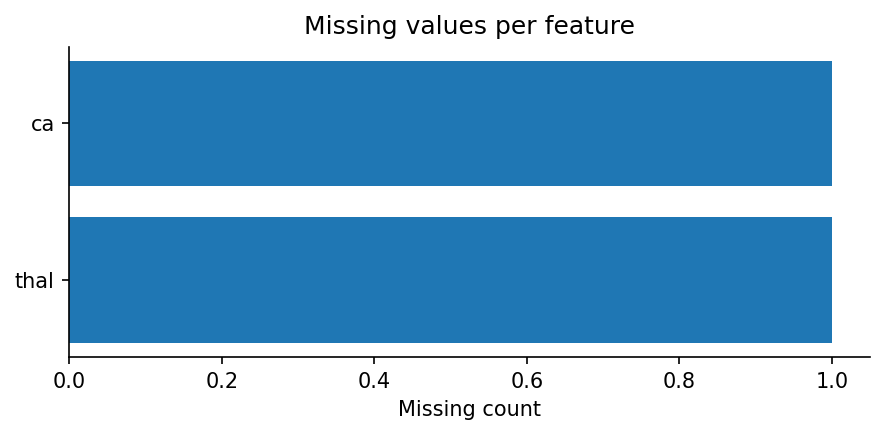

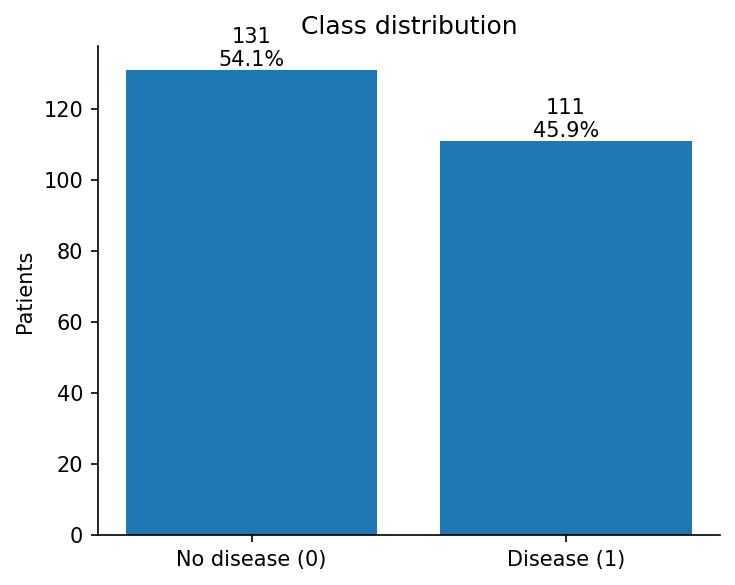

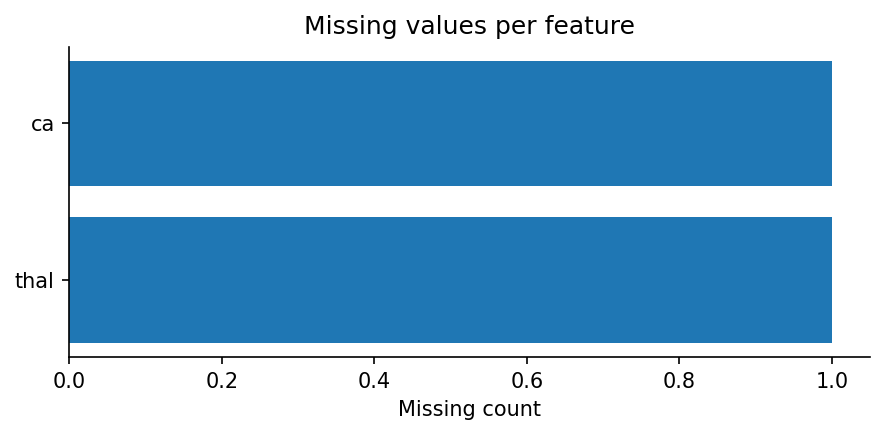

In [3]:
plotting.plot_class_distribution(y)
plotting.plot_missing_values(X)

The target class distrbution is midly imbalanced. 131 patients (54.1%) belonging to the healthy class and 111 patients (45.9%) belonging to the heart-disease class. We account for this with stratified cross-split.

## Feature distributions

Boxplots provide a first view of class separation in continuous clinical variables.

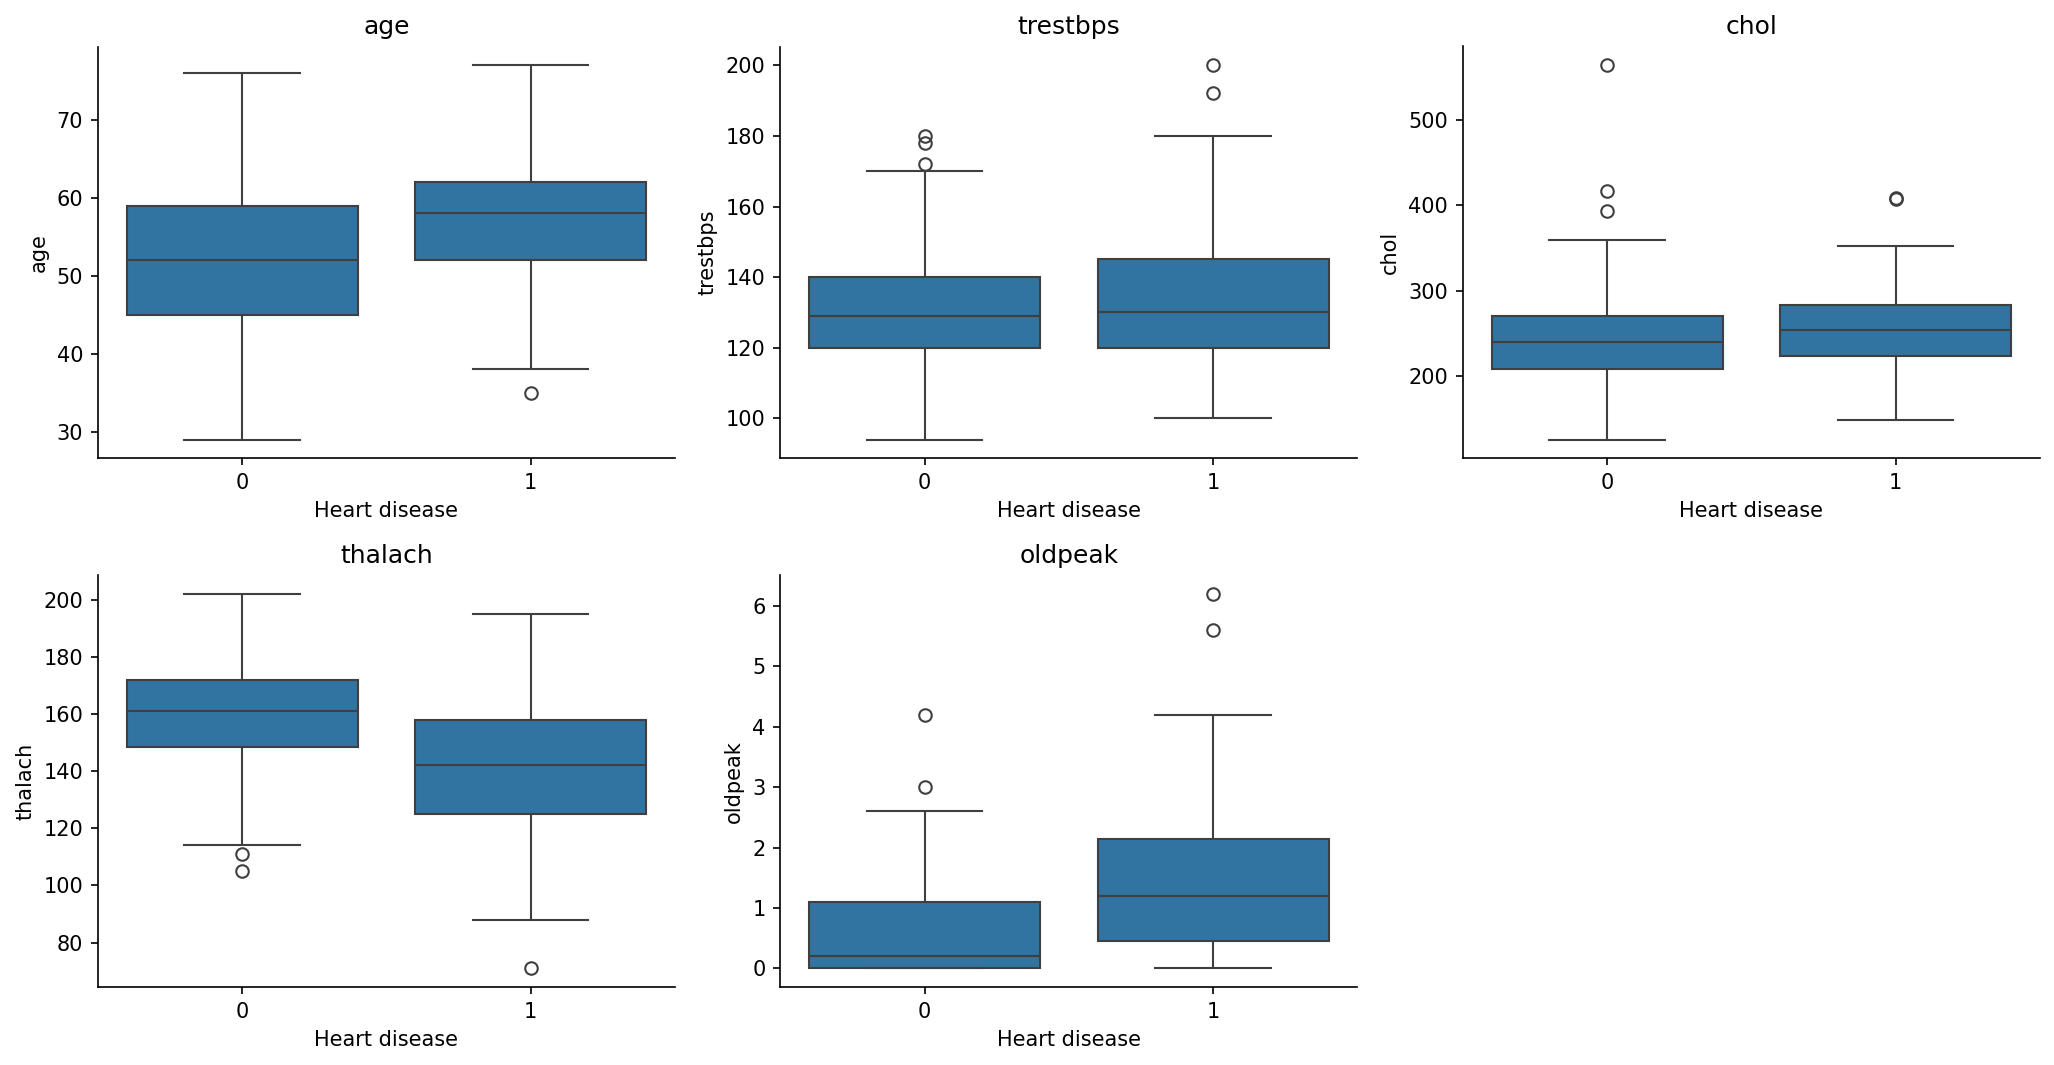

In [4]:
plotting.plot_feature_boxplots(X, y, CONTINUOUS_FEATURES);

Boxplots of the continuous clinical variables revealed noticeable differences between patients with and without heart disease. Patients with heart disease generally appeared older, exhibited lower maximum heart rate during exercise (`thalach`), and showed substantially higher ST depression values (`oldpeak`). Resting blood pressure (`trestbps`) and cholesterol (`chol`) displayed weaker separation between the two groups, although several high-value outliers were observed. The presence of outliers further justified the use of median imputation during preprocessing, as it is more robust than mean imputation for skewed clinical measurements.

## Correlation analysis

Spearman correlations are useful because several variables are ordinal or non-normally distributed.

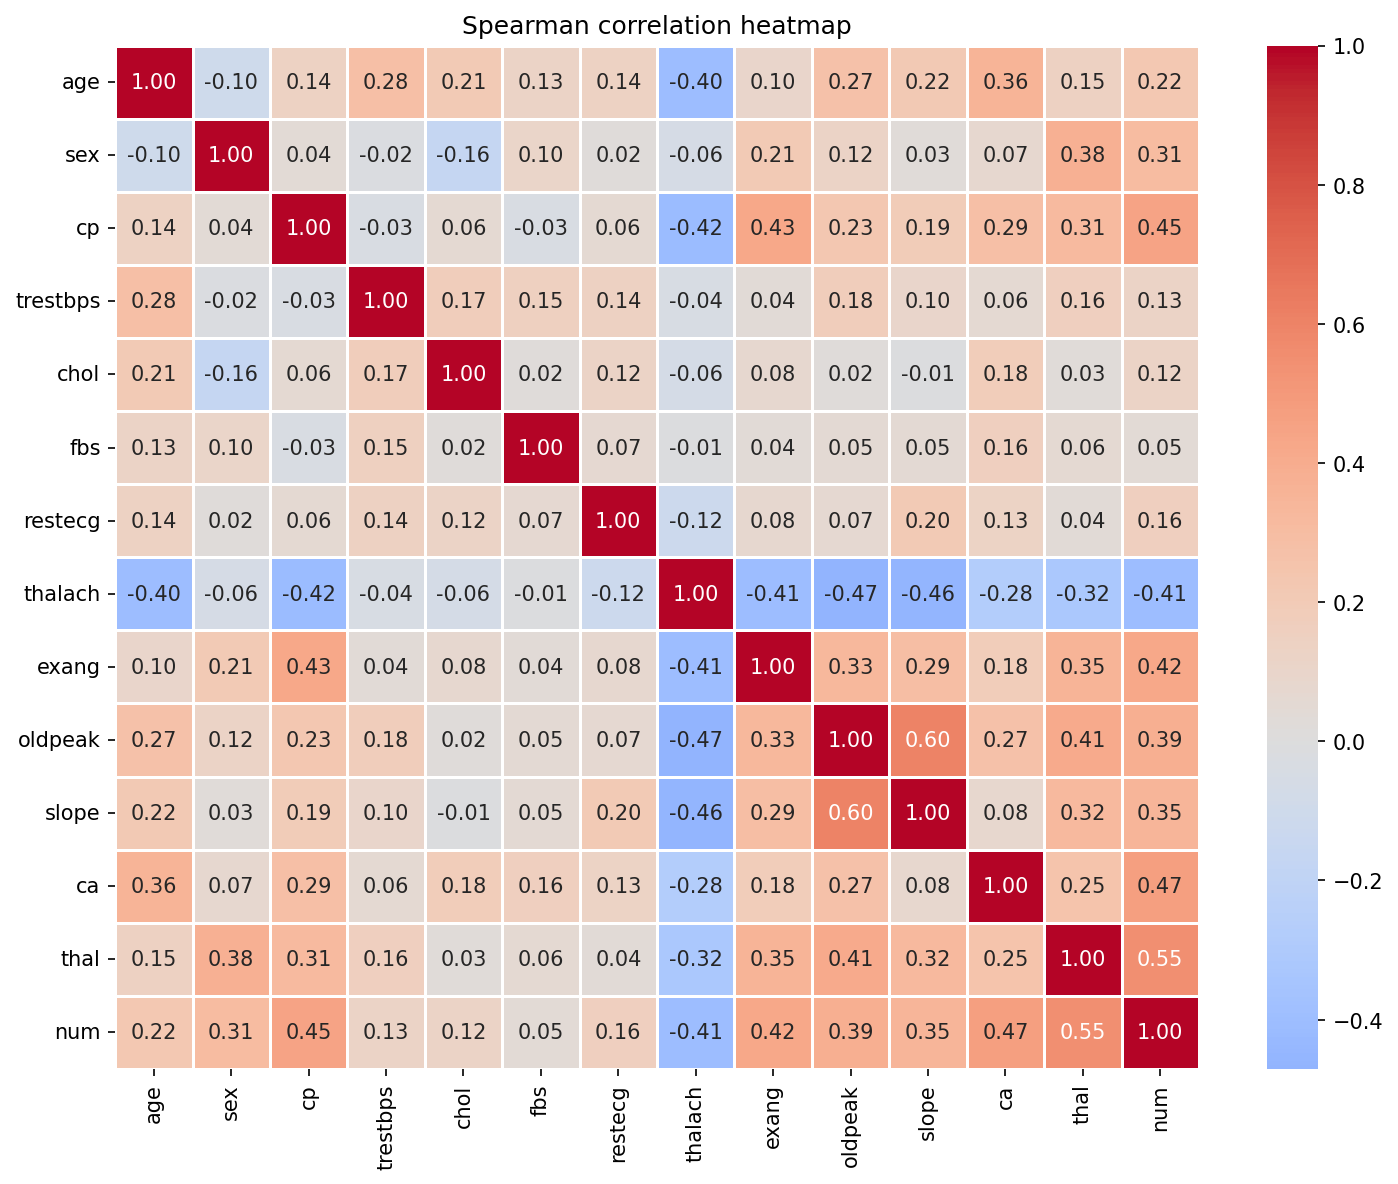

In [5]:
plotting.plot_correlation_heatmap(X, y);

Spearman correlation analysis revealed several clinically meaningful relationships between variables and the target label (`num`). The strongest positive correlations with heart disease were observed for `thal` (ρ = 0.55), `ca` (ρ = 0.47), `cp` (ρ = 0.45), and `exang` (ρ = 0.42), while `thalach` showed a moderate negative correlation (ρ = -0.41), indicating that lower exercise heart rate was associated with disease presence. Moderate correlations were also observed between some predictors, particularly `oldpeak` and `slope` (ρ = 0.60), suggesting partial feature redundancy. However, no extreme multicollinearity patterns were detected, allowing all features to be retained during initial modelling.

## PCA visualization

For visualization only, the raw-data preprocessor is fitted once here. This is not used for model evaluation.

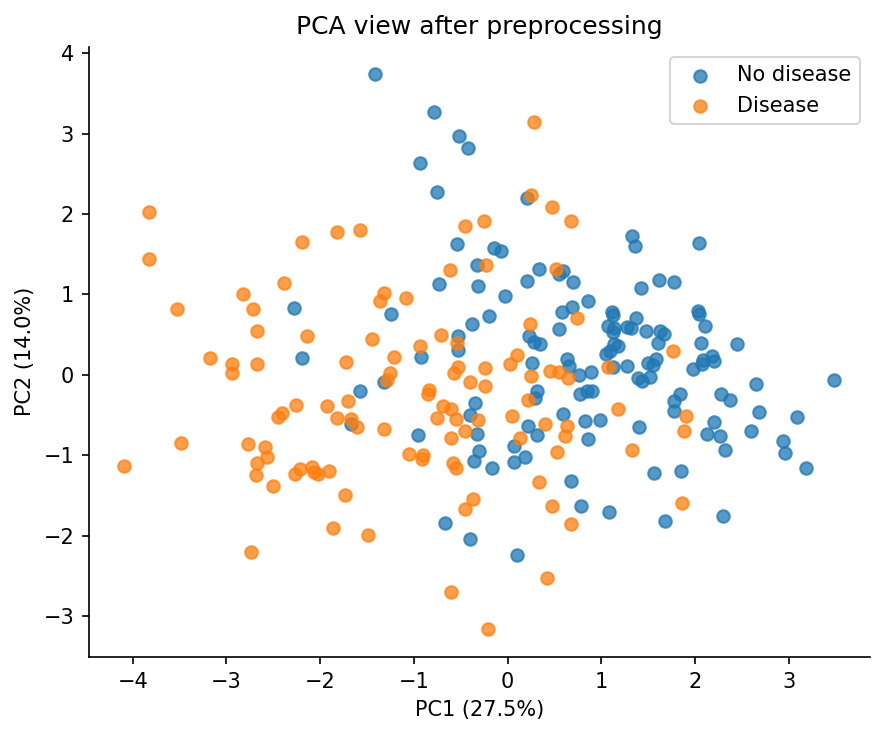

In [6]:
preprocessor = make_preprocessor()
plotting.plot_pca_from_pipeline(preprocessor, X, y);

Principal Component Analysis was applied after preprocessing to obtain a low-dimensional visualization of the feature space. The first two principal components explained 27.5% and 14.0% of the total variance, respectively. Partial separation between healthy and diseased patients was observed, although substantial overlap remained between the two classes. This indicates that the classification problem is not linearly separable in a simple two-dimensional space and supports the use of supervised machine learning models capable of learning more complex decision boundaries.

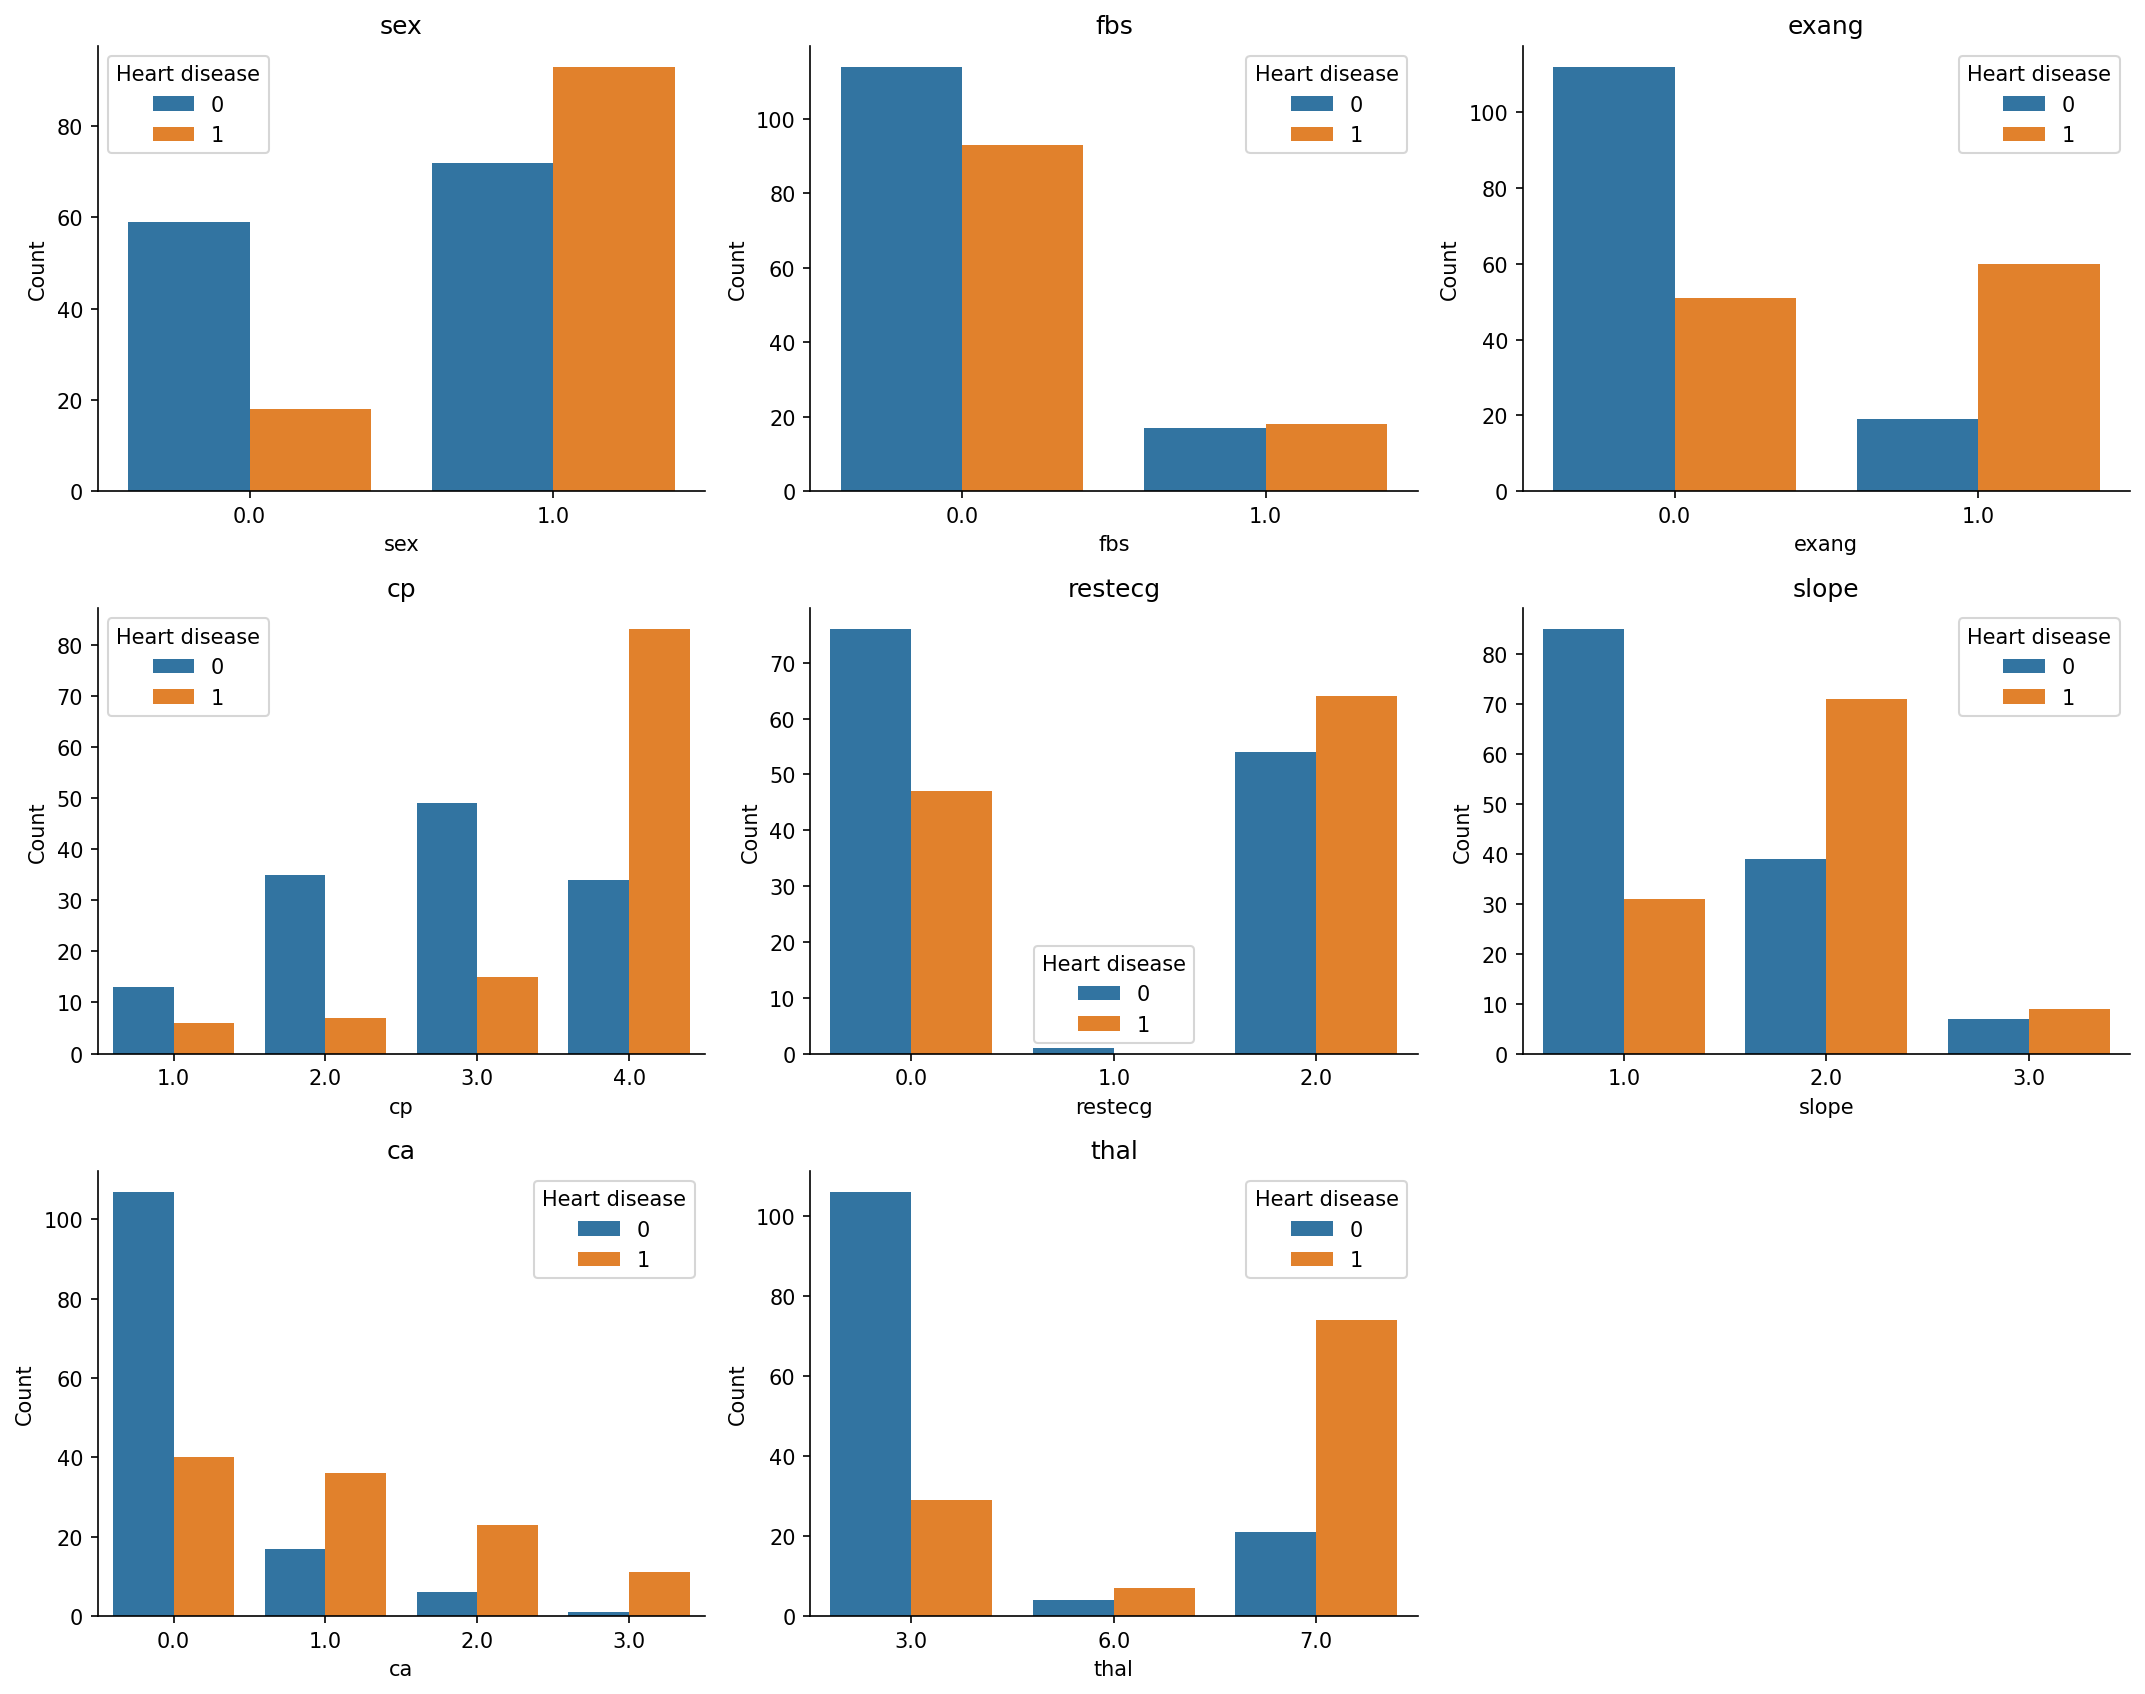

In [9]:
binary_and_categorical = [
    'sex',
    'fbs',
    'exang',
    'cp',
    'restecg',
    'slope',
    'ca',
    'thal'
]

eda_df = X.copy()
eda_df['num'] = y.values

plotting.plot_categorical_distributions(
    eda_df,
    target_col='num',
    cols=binary_and_categorical,
    save=True
);